In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Logic**:

*Long Only*
1. On daily basis, choose stocks within top 20% sentiment score
2. Get sum of weighted returns of the stock.
3. Repeat Steps 1 and 2 for the next day.

*Short Only*
1. On daily basis, choose stocks within bottom 20% sentiment score
2. Get sum of weighted returns of the stock.
3. Repeat Steps 1 and 2 for the next day.

Notes:
- Download 500 stock prices in single dataframe from yfinance
- Each day, store the list of stocks to pick in a separate dict {date: list of stocks}
- Get portfolio daily returns (pct_change().shift(-1) for selected stocks and take average)

In [153]:
def pick_stocks(sentiment_df, long_short='long', percentile=0.2):

    if long_short =='long':
        top_tickers_dict = (
            sentiment_df.groupby(['date', 'ticker'])['score'].mean()
            .reset_index()
            .sort_values(['date', 'score'], ascending=[True, False])
            .groupby('date')
            .apply(lambda group: group['ticker'].head(max(1, int(len(group) * percentile))).tolist())
            .to_dict()
        )
        
    elif long_short == 'short':
            top_tickers_dict = (
            sentiment_df.groupby(['date', 'ticker'])['score'].mean()
            .reset_index()
            .sort_values(['date', 'score'], ascending=[True, True])
            .groupby('date')
            .apply(lambda group: group['ticker'].head(max(1, int(len(group) * percentile))).tolist())
            .to_dict()
        )
    return top_tickers_dict


In [157]:
class Portfolio:
    def __init__(self, price_df, long_short=None, long_tickers_dict=None, short_tickers_dict=None):
        self.price_df = price_df
        self.long_short = long_short
        self.long_tickers_dict = long_tickers_dict
        self.short_tickers_dict = short_tickers_dict
        self.portfolio_returns = None
        
    def calculate_portfolio_returns(self):
        portfolio_returns = {}
        returns_df = self.price_df.pct_change().shift(-1).copy()
        
        if self.long_short is None:
            print('No strategy selected!')
            return None
        
        if self.long_tickers_dict is None and self.short_tickers_dict is None:
            print('No stocks selected!')
            return None

        elif self.long_short == 'long' and self.long_tickers_dict:
            for idx in returns_df.index:
                if idx in self.long_tickers_dict:
                    tickers = self.long_tickers_dict[idx]
                else:
                    tickers = []
                portfolio_returns[idx] = returns_df.loc[idx][tickers].mean()

        elif self.long_short == 'short' and self.short_tickers_dict:
            for idx in returns_df.index:
                if idx in self.short_tickers_dict:
                    tickers = self.short_tickers_dict[idx]
                else:
                    tickers = []
                portfolio_returns[idx] = -returns_df.loc[idx][tickers].mean()

        elif self.long_short == 'long_short' and self.short_tickers_dict and self.long_tickers_dict:
            for idx in returns_df.index:
                if idx in self.short_tickers_dict:
                    short_tickers = self.short_tickers_dict[idx]
                else:
                    short_tickers = []

                if idx in self.long_tickers_dict:
                    long_tickers = self.long_tickers_dict[idx]
                else:
                    long_tickers = []

                portfolio_returns[idx] = (returns_df.loc[idx][long_tickers].sum() - returns_df.loc[idx][short_tickers].sum()) / len(long_tickers + short_tickers)
        
        else:
            print('Error or combination not correct')
            return None
        
        # Convert portfolio returns to DataFrame
        self.portfolio_returns = pd.DataFrame(list(portfolio_returns.items()), columns=['Date', 'Portfolio_returns']).fillna(0)

        # Calculate cumulative returns
        self.portfolio_returns['Cumulative_returns'] = (1 + self.portfolio_returns['Portfolio_returns']).cumprod() - 1
        
        return self.portfolio_returns
    
    def calculate_sharpe_ratio(self, risk_free_rate=0.0):
        if self.portfolio_returns is None:
            print("Portfolio returns are not calculated. Please calculate returns first.")
            return None
        
        # Calculate average daily return and daily standard deviation
        avg_daily_return = self.portfolio_returns['Portfolio_returns'].mean()
        daily_std_dev = self.portfolio_returns['Portfolio_returns'].std()
        
        # Annualize the return and standard deviation
        annualized_return = avg_daily_return * 252  # 252 trading days in a year
        annualized_std_dev = daily_std_dev * np.sqrt(252)
        
        # Calculate annualized Sharpe ratio
        sharpe_ratio = (annualized_return - risk_free_rate) / annualized_std_dev
        return sharpe_ratio
    
    def plot_cumulative_returns(self):
        if self.portfolio_returns is None:
            print("Portfolio returns are not calculated. Please calculate returns first.")
            return None
        
        # Calculate cumulative returns
        self.portfolio_returns['Cumulative_returns'] = (1 + self.portfolio_returns['Portfolio_returns']).cumprod() - 1
        
        # Plot cumulative returns
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.plot(self.portfolio_returns['Date'], self.portfolio_returns['Cumulative_returns'], label='Cumulative Portfolio Returns')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return')
        plt.title('Portfolio Cumulative Returns')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    def calculate_total_return(self):
        """Calculate the total return of the strategy."""
        total_return = self.portfolio_returns['Cumulative_returns'].iloc[-1]
        return total_return
    

    def run_backtest(self):
        """Run the backtest and return key metrics."""
        self.calculate_portfolio_returns()
        sharpe_ratio = self.calculate_sharpe_ratio()
        total_return = self.calculate_total_return()
        
        self.plot_cumulative_returns()
        
        return {
            'Sharpe Ratio': sharpe_ratio,
            'Total Return': total_return
        }

# Sample Data

In [ ]:
# Sample DataFrame
import random 
# List of tickers and dates
tickers = ['AAPL', 'GOOGL', 'MSFT',]
dates = pd.date_range('2024-11-01', '2024-11-30', freq='B')  # Business days in November 2024

# Sample data creation
data = []

for date in dates:
    for ticker in tickers:
        title = f"Title{random.randint(1, 10)}"
        score = round(random.uniform(0.5, 1.0), 2)  # Random score between 0.5 and 1.0
        data.append([date, title, ticker, score])

# Create the DataFrame
df = pd.DataFrame(data, columns=['date', 'title', 'ticker', 'score'])

# df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])

In [162]:
stock_dict = pick_stocks(df, long_short='long', percentile=0.7)

In [167]:
import yfinance as yf

prices = yf.download(['AAPL', 'MSFT', 'GOOGL'], start='2024-11-01', end='2024-12-01', multi_level_index=False)['Adj Close']

[*********************100%***********************]  3 of 3 completed


In [165]:
prices

Ticker,AAPL,GOOGL,MSFT
Date,,,
2024-11-01,222.665024,171.093903,409.550232
2024-11-04,221.766006,169.046265,407.644043
2024-11-05,223.204422,169.545700,410.638031
2024-11-06,222.475235,176.307938,419.340607
2024-11-07,227.229996,180.543091,424.580139
2024-11-08,226.960007,178.145844,421.695923
2024-11-11,224.229996,180.143555,417.174957
2024-11-12,224.229996,181.412079,422.184937
2024-11-13,225.119995,178.675232,424.350616


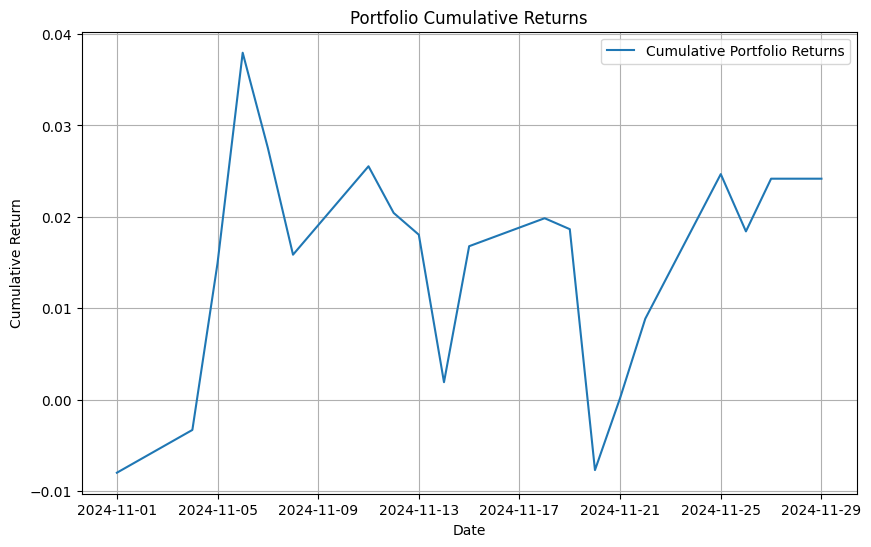

{'Sharpe Ratio': 1.6384617642173116, 'Total Return': 0.024176926215187633}

In [171]:
x = Portfolio(prices, long_short='long', long_tickers_dict=stock_dict)
# x.calculate_portfolio_returns()
# x.plot_cumulative_returns()
x.run_backtest()